In [1]:
# change kernel to widget
import xarray as xr
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
#%matplotlib widget

In [2]:
ds0 = xr.open_dataset('ncqs0_hourly_pertransect.nc')  
ds1 = xr.open_dataset('ncqs1_hourly_pertransect.nc')  
ds2 = xr.open_dataset('ncqs2_hourly_pertransect.nc')  
ds3 = xr.open_dataset('ncqs3_hourly_pertransect.nc')  
#ds = ds1+ds2+ds3+ds0

In [3]:
# perpare landsat mosaic
red_files = ['LC08_L2SP_014035_20170409_20200904_02_T1_SR_B4.TIF', 'LC08_L2SP_014036_20170409_20200904_02_T1_SR_B4.TIF', 'LC08_L2SP_015036_20170502_20200904_02_T1_SR_B4.TIF', 'LC08_L2SP_014036_20170527_20200903_02_T1_SR_B4.TIF']
green_files = ['LC08_L2SP_014035_20170409_20200904_02_T1_SR_B3.TIF', 'LC08_L2SP_014035_20170409_20200904_02_T1_SR_B3.TIF', 'LC08_L2SP_015036_20170502_20200904_02_T1_SR_B3.TIF', 'LC08_L2SP_014036_20170527_20200903_02_T1_SR_B3.TIF']
blue_files = ['LC08_L2SP_014035_20170409_20200904_02_T1_SR_B2.TIF', 'LC08_L2SP_014036_20170409_20200904_02_T1_SR_B2.TIF', 'LC08_L2SP_015036_20170502_20200904_02_T1_SR_B2.TIF', 'LC08_L2SP_014036_20170527_20200903_02_T1_SR_B2.TIF']

def mosaic_band(file_list):
    """Opens a list of TIFs and merges them into one array."""
    elements = [rxr.open_rasterio(f, masked=True).squeeze() for f in file_list]
    return merge_arrays(elements)

print("Mosaicking bands... ")
merged_red = mosaic_band(red_files)
merged_green = mosaic_band(green_files)
merged_blue = mosaic_band(blue_files)

rgb = xr.concat([merged_red, merged_green, merged_blue], dim='band')
rgb['band'] = [1, 2, 3]

rgb_scaled = (rgb / 20000).clip(0, 1)
print('Done! :)')

Mosaicking bands... 
Done! :)


In [3]:
sum_transport = ds['qs'].sum(dim='time').compute()
mean_lon = ds['lon']
mean_lat = ds['lat']

gdf = gpd.GeoDataFrame(
    {'qs': sum_transport.values},
    geometry=gpd.points_from_xy(mean_lon, mean_lat),
    crs="EPSG:4326"
)
gdf = gdf.to_crs(rgb.rio.crs)

fig, ax = plt.subplots(figsize=(15, 15))

rgb_scaled.plot.imshow(rgb='band', ax=ax)

limit = max(abs(np.nanmax(sum_transport)), abs(np.nanmin(sum_transport)))
scatter = ax.scatter(
    gdf.geometry.x, 
    gdf.geometry.y, 
    c=gdf['qs'],
    vmin=-limit, vmax=limit,
    cmap='RdBu', 
    s=25
)

plt.colorbar(scatter, label='Total Q_s', fraction=0.03, pad=0.04)
plt.title(f"Total Sediment Flux (1980-2023) over Landsat Mosaic")
# ax.set_axis_off() # hides UTM coordinates
plt.show()

NameError: name 'ds' is not defined

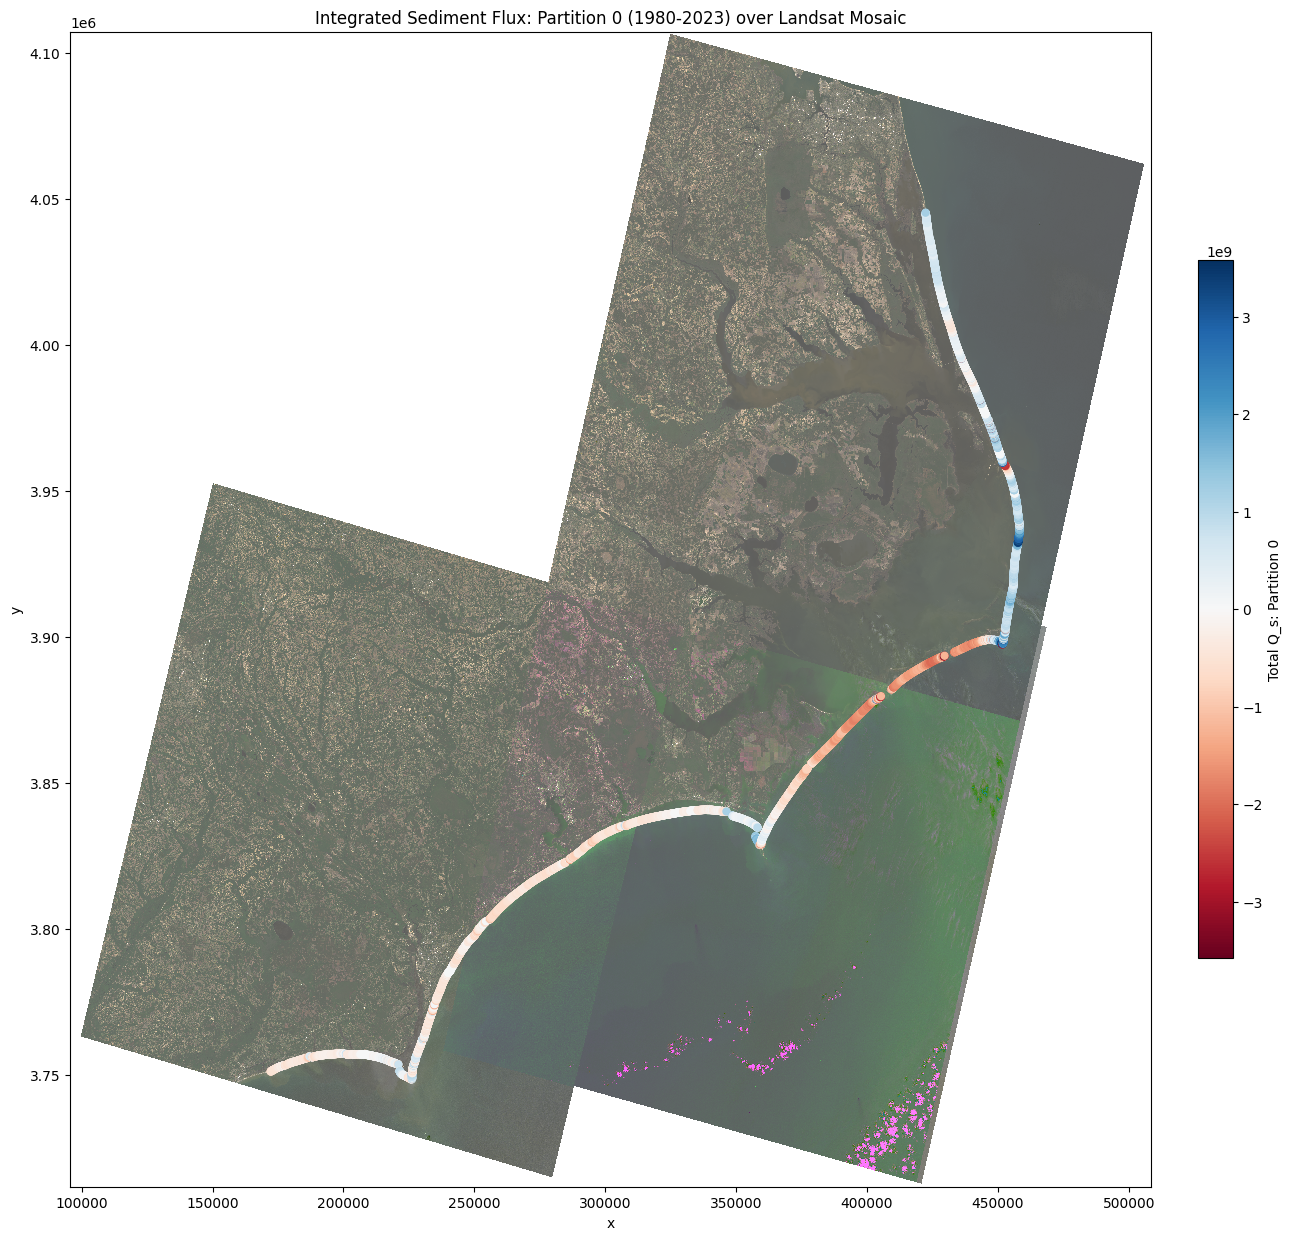

In [4]:
# plot cumulative qs for sea
sum_transport_0 = (ds0['qs'].sum(dim='time').compute())*385714 # times hours for integration
mean_lon = ds0['lon']
mean_lat = ds0['lat']

gdf = gpd.GeoDataFrame(
    {'qs': sum_transport_0.values},
    geometry=gpd.points_from_xy(mean_lon, mean_lat),
    crs="EPSG:4326"
)
gdf = gdf.to_crs(rgb.rio.crs)

fig, ax = plt.subplots(figsize=(15, 15))

rgb_scaled.plot.imshow(rgb='band', ax=ax)

limit = max(abs(np.nanmax(sum_transport_0)), abs(np.nanmin(sum_transport_0)))
scatter = ax.scatter(
    gdf.geometry.x, 
    gdf.geometry.y, 
    c=gdf['qs'],
    vmin=-limit, vmax=limit,
    cmap='RdBu', 
    s=25
)

plt.colorbar(scatter, label='Total Q_s: Partition 0', fraction=0.03, pad=0.04)
plt.title(f"Integrated Sediment Flux: Partition 0 (1980-2023) over Landsat Mosaic")
# ax.set_axis_off() # hides UTM coordinates
plt.show()

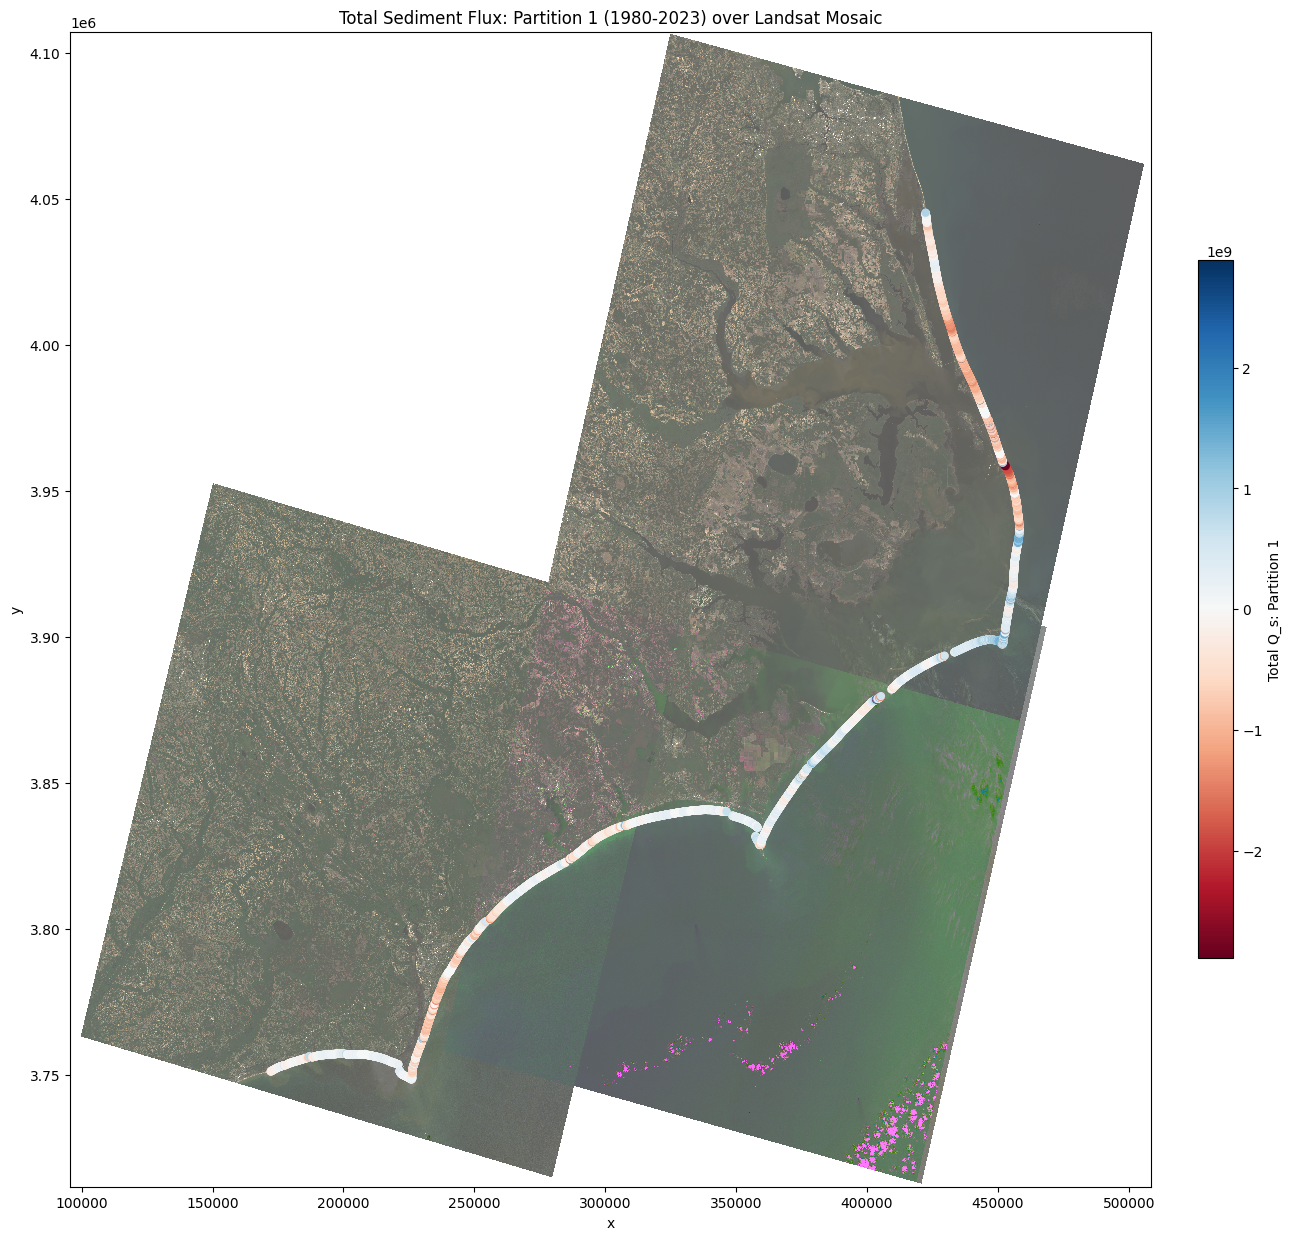

In [4]:
# plot cumulative qs for swell partition 1
sum_transport_1 = (ds1['qs'].sum(dim='time').compute())*385714
mean_lon = ds1['lon']
mean_lat = ds1['lat']

gdf = gpd.GeoDataFrame(
    {'qs': sum_transport_1.values},
    geometry=gpd.points_from_xy(mean_lon, mean_lat),
    crs="EPSG:4326"
)
gdf = gdf.to_crs(rgb.rio.crs)

fig, ax = plt.subplots(figsize=(15, 15))

rgb_scaled.plot.imshow(rgb='band', ax=ax)

limit = max(abs(np.nanmax(sum_transport_1)), abs(np.nanmin(sum_transport_1)))
scatter = ax.scatter(
    gdf.geometry.x, 
    gdf.geometry.y, 
    c=gdf['qs'],
    vmin=-limit, vmax=limit,
    cmap='RdBu', 
    s=25
)

plt.colorbar(scatter, label='Total Q_s: Partition 1', fraction=0.03, pad=0.04)
plt.title(f"Total Sediment Flux: Partition 1 (1980-2023) over Landsat Mosaic")
# ax.set_axis_off() # hides UTM coordinates
plt.show()